### Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import f1_score as f1_metric
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

ModuleNotFoundError: No module named 'pandas'

### Load Dataset

In [3]:
df = pd.read_csv('./dataset/credit-card-no-sintetic.csv')
print(df.shape)

(284807, 31)


### Start With the EDA (Exploratory Data Analysis)

**Get the type of columns in the dataset**

In [4]:
print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


**Inspect the resume of the data:**

* It displays that the 1% of the data are frauds
* There are 1000 rows in each column
* Even distribution
* The values in the “amount” column lead us to suspect that the dataset is synthetic

In [5]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

**Detect null values in the dataset**

In [6]:
print(df.isna().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


**View the distribution in IsFraud**

Class
0    284315
1       492
Name: count, dtype: int64


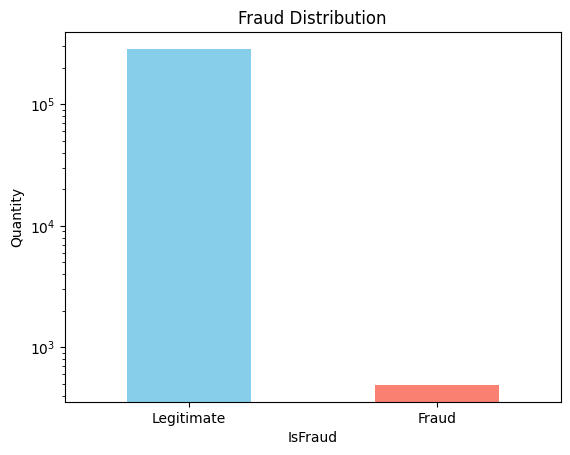

In [7]:
fraud_distribution = df['Class'].value_counts()
print(fraud_distribution)
fraud_distribution.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Fraud Distribution')
plt.yscale('log')
plt.xlabel('IsFraud')
plt.ylabel('Quantity')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.show()

**View the Amount distribution**

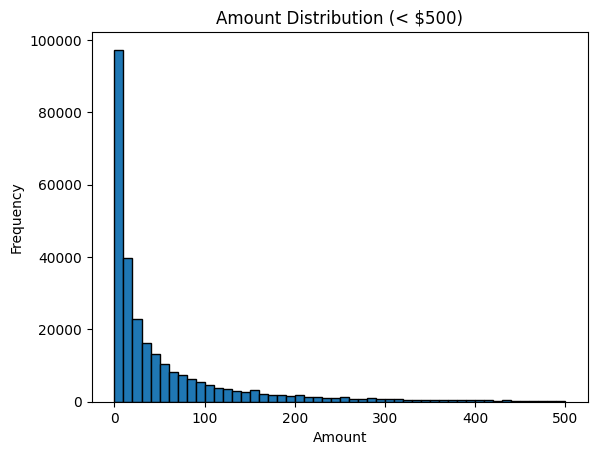

In [13]:
df[df['Amount'] < 500]['Amount'].plot(kind='hist', edgecolor='black', bins=50)
plt.title('Amount Distribution (< $500)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

### Preprocessing

**First, drop the ids columns (TransactionID & MerchantID)**

In [14]:
df_clean = df.copy()

df_clean = df.drop(['Time'], axis=1)
print(df_clean.columns)

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')


**Divide Target & Features**

In [15]:
y = df_clean['Class']

X = df_clean.drop('Class', axis=1)

### Separate Between Train & Test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

### Scale the Amount column with RobustScaler

In [17]:
scaler = RobustScaler()
scaler.fit(X_train[['Amount']])

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [18]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Amount']] = scaler.transform(X_train_scaled[['Amount']])
X_test_scaled[['Amount']] = scaler.transform(X_test_scaled[['Amount']])

### Logistic Regression

1. **Train model**
2. **Get the coefficients**
3. **Test the model**
4. **Get the metrics**

In [22]:
mlflow.set_experiment('credit-card-fraud-detection-no-sintetic')

with mlflow.start_run(run_name='logistic-regression-baseline'):
    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train_scaled, y_train)
    mlflow.log_params({'max_iter': 1000})

    df_log_model = pd.DataFrame({
        'Variable': X_train_scaled.columns,
        'Weight': log_model.coef_[0],
    })

    df_log_model.to_csv('coeffs/coefficients.csv', index=False)
    mlflow.log_artifact('coeffs/coefficients.csv')

    y_pred = log_model.predict(X_test_scaled)
    f1 = (f1_metric(y_test, y_pred, pos_label=1))
    roc_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1])
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1)

    mlflow.log_metrics({'f1-score': f1, 'roc-auc': roc_auc, 'precision': precision, 'recall': recall})

In [23]:
print(df_log_model)

   Variable    Weight
0        V1  0.016776
1        V2  0.030677
2        V3 -0.000839
3        V4  0.640312
4        V5  0.058934
5        V6 -0.136982
6        V7  0.030077
7        V8 -0.214298
8        V9 -0.109161
9       V10 -0.517105
10      V11  0.057146
11      V12 -0.027175
12      V13 -0.321070
13      V14 -0.613235
14      V15 -0.108784
15      V16 -0.306021
16      V17  0.025851
17      V18 -0.034894
18      V19  0.024225
19      V20 -0.180352
20      V21  0.327928
21      V22  0.518037
22      V23 -0.117379
23      V24  0.091038
24      V25 -0.133715
25      V26 -0.066088
26      V27 -0.235841
27      V28  0.036963
28   Amount  0.013104


In [24]:
print('precision',precision)
print('recall', recall)
print('f1',f1)
print("ROC-AUC:", roc_auc)

precision 0.8505747126436781
recall 0.7474747474747475
f1 0.7956989247311828
ROC-AUC: 0.9924770452178434


### Random Forest

In [ ]:
mlflow.set_experiment('credit-card-fraud-detection')

with mlflow.start_run(run_name='random-forest-regression-baseline'):
    random_forest_model = RandomForestClassifier(n_estimators=100, random_state=23)
    random_forest_model.fit(X_train_scaled, y_train)
    mlflow.log_params({'n_estimators': 100, 'random_state': 23})

    df_rf_model = pd.DataFrame({
        'Variable': X_train_scaled.columns,
        'Criterion': random_forest_model.criterion,
    })

    df_rf_model.to_csv('coeffs/coefficients_random.csv', index=False)
    mlflow.log_artifact('coeffs/coefficients_random.csv')

    y_pred = random_forest_model.predict(X_test_scaled)
    f1 = (f1_metric(y_test, y_pred, pos_label=1))
    roc_auc = roc_auc_score(y_test, random_forest_model.predict_proba(X_test_scaled)[:, 1])
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1)

    mlflow.log_metrics({'f1-score': f1, 'roc-auc': roc_auc, 'precision': precision, 'recall': recall})

In [26]:
print(df_rf_model)

   Variable Criterion
0        V1      gini
1        V2      gini
2        V3      gini
3        V4      gini
4        V5      gini
5        V6      gini
6        V7      gini
7        V8      gini
8        V9      gini
9       V10      gini
10      V11      gini
11      V12      gini
12      V13      gini
13      V14      gini
14      V15      gini
15      V16      gini
16      V17      gini
17      V18      gini
18      V19      gini
19      V20      gini
20      V21      gini
21      V22      gini
22      V23      gini
23      V24      gini
24      V25      gini
25      V26      gini
26      V27      gini
27      V28      gini
28   Amount      gini


In [27]:
print(precision)
print(recall)
print(f1)
print("ROC-AUC:", roc_auc)

0.9473684210526315
0.9090909090909091
0.9278350515463918
ROC-AUC: 0.9893819754977273
